<a href="https://colab.research.google.com/github/riteshkushwaha7/ML/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
data=  load_breast_cancer()
X_train,X_test, Y_train, Y_test = train_test_split(data.data, data.target, test_size=0.2)

In [5]:
scaler = StandardScaler()
X_train_Scaled = scaler.fit_transform(X_train)
X_test_Scaled = scaler.fit_transform(X_test)

In [8]:
model = LogisticRegression()
model.fit(X_train_Scaled,Y_train)
print(model.score(X_test_Scaled, Y_test))

0.9649122807017544


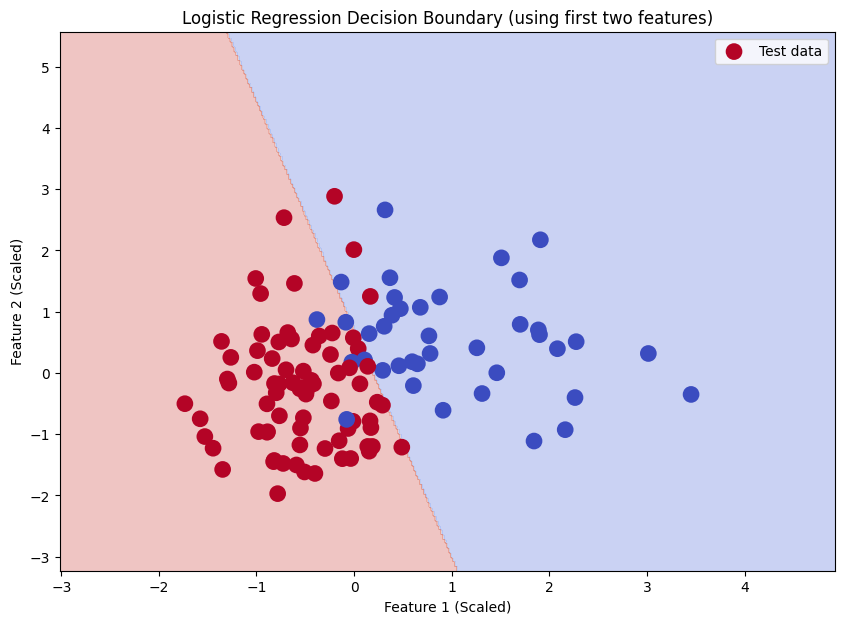

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression

X_train_2d = X_train_Scaled[:, :2]
X_test_2d = X_test_Scaled[:, :2]

model_2d = LogisticRegression()
model_2d.fit(X_train_2d, Y_train)

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=Y_test, cmap=plt.cm.coolwarm, s=100, linewidths=2, label='Test data')

plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.title('Logistic Regression Decision Boundary (using first two features)')
plt.legend()
plt.show()